## Model

In [1]:
import os
from dotenv import load_dotenv
load_dotenv()

True

In [2]:
API_key = os.getenv("GOOGLE_API_KEY")
llm_model = "gemini-2.5-flash"

In [3]:
os.environ["LANGCHAIN_PROJECT"] = "Trim and Filter"

In [4]:
from langchain_google_genai import ChatGoogleGenerativeAI

In [47]:
model = ChatGoogleGenerativeAI(
                    model=llm_model,
                    temperature=0,
                    timeout=None,
                    max_retries=2)

# Messages as state

In [5]:
from pprint import pprint
from langchain_core.messages import AIMessage, HumanMessage
messages = [AIMessage(f"So you said you were researching ocean mammals?", name="Bot")]
messages.append(HumanMessage(f"Yes, I know about whales. But what others should I learn about?", name="Lance"))

for m in messages:
    m.pretty_print()

================================== Ai Message ==================================
Name: Bot

So you said you were researching ocean mammals?
================================ Human Message =================================
Name: Lance

Yes, I know about whales. But what others should I learn about?


In [8]:
model.invoke(messages)

AIMessage(content='Excellent! Beyond whales (which are cetaceans, including dolphins and porpoises), the ocean is teeming with other incredible mammals. Here are the main groups you should definitely learn about:', additional_kwargs={}, response_metadata={'finish_reason': 'MAX_TOKENS', 'model_name': 'gemini-2.5-flash', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019d2e11-8920-7360-b605-f2f0bdec623b-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 26, 'output_tokens': 996, 'total_tokens': 1022, 'input_token_details': {'cache_read': 0}, 'output_token_details': {'reasoning': 959}})

- We can run our chat model in a simple graph with MessagesState.

In [9]:
from IPython.display import Image, display
from langgraph.graph import MessagesState
from langgraph.graph import StateGraph, START, END 

In [14]:
# Node
def chat_model_node(state: MessagesState):
    return {"messages": model.invoke(state["messages"])}

In [15]:
# Build graph
builder = StateGraph(MessagesState)
builder.add_node("chat_model", chat_model_node)
builder.add_edge(START, "chat_model")
builder.add_edge("chat_model", END)
graph = builder.compile()

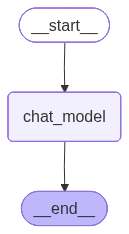

In [16]:
display(Image(graph.get_graph().draw_mermaid_png()))

In [17]:
output = graph.invoke({'messages': messages})
for m in output['messages']:
    m.pretty_print()

================================== Ai Message ==================================
Name: Bot

So you said you were researching ocean mammals?
================================ Human Message =================================
Name: Lance

Yes, I know about whales. But what others should I learn about?
================================== Ai Message ==================================

That's a great question! While whales (and their close relatives, dolphins and porpoises) are fascinating, the ocean is home to many other incredible mammals. Here are some of


# Reducer

- Long-running conversations result in high token usage and latency if we are not careful, because we pass a growing list of messages to the model.

In [18]:
from langchain_core.messages import RemoveMessage

In [19]:
# Nodes
def filter_messages(state: MessagesState):
    # Delete all but the 2 most recent messages
    delete_messages = [RemoveMessage(id=m.id) for m in state["messages"][:-2]]
    return {"messages": delete_messages}

In [27]:
def chat_model_node(state: MessagesState):    
    return {"messages": [model.invoke(state["messages"])]}

In [28]:
# Build graph
builder = StateGraph(MessagesState)

In [29]:
builder.add_node("filter", filter_messages)
builder.add_node("chat_model", chat_model_node)

In [30]:
builder.add_edge(START, "filter")
builder.add_edge("filter", "chat_model")
builder.add_edge("chat_model", END)
graph = builder.compile()

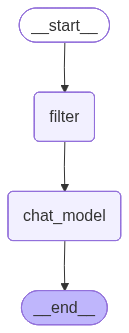

In [31]:
display(Image(graph.get_graph().draw_mermaid_png()))

In [32]:
# Message list with a preamble
messages = [AIMessage("Hi.", name="Bot", id="1")]
messages.append(HumanMessage("Hi.", name="Lance", id="2"))
messages.append(AIMessage("So you said you were researching ocean mammals?", name="Bot", id="3"))
messages.append(HumanMessage("Yes, I know about whales. But what others should I learn about?", name="Lance", id="4"))

In [33]:
# Invoke
output = graph.invoke({'messages': messages})
for m in output['messages']:
    m.pretty_print()

================================== Ai Message ==================================
Name: Bot

So you said you were researching ocean mammals?
================================ Human Message =================================
Name: Lance

Yes, I know about whales. But what others should I learn about?
================================== Ai Message ==================================

That's a great question! While whales (and their close relatives, dolphins and porpoises) are fascinating, the ocean is home to many other incredible mammals. Here are some of


# Filtering messages

In [36]:
# Node
def chat_model_node(state: MessagesState):
    return {"messages": [model.invoke(state["messages"][-1:])]}

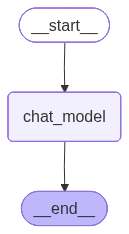

In [37]:
# Build graph
builder = StateGraph(MessagesState)
builder.add_node("chat_model", chat_model_node)
builder.add_edge(START, "chat_model")
builder.add_edge("chat_model", END)
graph = builder.compile()

# View
display(Image(graph.get_graph().draw_mermaid_png()))

In [38]:
messages.append(output['messages'][-1])
messages.append(HumanMessage(f"Tell me more about Narwhals!", name="Lance"))

In [39]:
for m in messages:
    m.pretty_print()

================================== Ai Message ==================================
Name: Bot

Hi.
================================ Human Message =================================
Name: Lance

Hi.
================================== Ai Message ==================================
Name: Bot

So you said you were researching ocean mammals?
================================ Human Message =================================
Name: Lance

Yes, I know about whales. But what others should I learn about?
================================== Ai Message ==================================

That's a great question! While whales (and their close relatives, dolphins and porpoises) are fascinating, the ocean is home to many other incredible mammals. Here are some of
================================ Human Message =================================
Name: Lance

Tell me more about Narwhals!


In [40]:
# Invoke, using message filtering
output = graph.invoke({'messages': messages})
for m in output['messages']:
    m.pretty_print()

================================== Ai Message ==================================
Name: Bot

Hi.
================================ Human Message =================================
Name: Lance

Hi.
================================== Ai Message ==================================
Name: Bot

So you said you were researching ocean mammals?
================================ Human Message =================================
Name: Lance

Yes, I know about whales. But what others should I learn about?
================================== Ai Message ==================================

That's a great question! While whales (and their close relatives, dolphins and porpoises) are fascinating, the ocean is home to many other incredible mammals. Here are some of
================================ Human Message =================================
Name: Lance

Tell me more about Narwhals!
================================== Ai Message ==================================

Narwhals are truly one of the most unique and

# Trim messages

- While filtering only returns a post-hoc subset of the messages between agents, trimming restricts the number of tokens that a chat model can use to respond.

In [48]:
from langchain_core.messages import trim_messages

In [55]:
def chat_model_node(state: MessagesState):
    messages = trim_messages(
            state["messages"],
            max_tokens=100,
            strategy="last",
            token_counter=model,
            allow_partial=False,
        )
    return {"messages": [model.invoke(messages)]}

In [56]:
# Build graph
builder = StateGraph(MessagesState)
builder.add_node("chat_model", chat_model_node)
builder.add_edge(START, "chat_model")
builder.add_edge("chat_model", END)
graph = builder.compile()

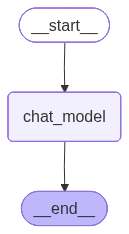

In [57]:
# View
display(Image(graph.get_graph().draw_mermaid_png()))

In [58]:
messages.append(output['messages'][-1])
messages.append(HumanMessage(f"Tell me where Orcas live!", name="Lance"))

In [59]:
# Example of trimming messages
trim_messages(
            messages,
            max_tokens=100,
            strategy="last",
            token_counter=model,
            allow_partial=False
        )

[AIMessage(content='Narwhals are truly one of the most unique and mysterious creatures of the Arctic! Often called the "unicorns of the sea" because of their distinctive long tusk, they are fascinating in', additional_kwargs={}, response_metadata={'finish_reason': 'MAX_TOKENS', 'model_name': 'gemini-2.5-flash', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019d2e21-1a79-79b0-a537-4bc4ed5740ae-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 9, 'output_tokens': 996, 'total_tokens': 1005, 'input_token_details': {'cache_read': 0}, 'output_token_details': {'reasoning': 957}}),
 HumanMessage(content='Tell me where Orcas live!', additional_kwargs={}, response_metadata={}, name='Lance', id='49ae42e7-868a-47a3-a6ee-837b94f9eda4'),
 AIMessage(content='Narwhals are truly one of the most unique and mysterious creatures of the Arctic! Often called the "unicorns of the sea" because of their distinctive long tusk, they are fascinating in', additional_k

In [60]:
# Invoke, using message trimming in the chat_model_node 
messages_out_trim = graph.invoke({'messages': messages})

In [61]:
messages_out_trim

{'messages': [AIMessage(content='Hi.', additional_kwargs={}, response_metadata={}, name='Bot', id='1', tool_calls=[], invalid_tool_calls=[]),
  HumanMessage(content='Hi.', additional_kwargs={}, response_metadata={}, name='Lance', id='2'),
  AIMessage(content='So you said you were researching ocean mammals?', additional_kwargs={}, response_metadata={}, name='Bot', id='3', tool_calls=[], invalid_tool_calls=[]),
  HumanMessage(content='Yes, I know about whales. But what others should I learn about?', additional_kwargs={}, response_metadata={}, name='Lance', id='4'),
  AIMessage(content="That's a great question! While whales (and their close relatives, dolphins and porpoises) are fascinating, the ocean is home to many other incredible mammals. Here are some of", additional_kwargs={}, response_metadata={'finish_reason': 'MAX_TOKENS', 'model_name': 'gemini-2.5-flash', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019d2e1c-8700-7953-8309-effaf103df69-0', tool_calls=[], 

In [63]:
for m in messages_out_trim['messages']:
    m.pretty_print()

================================== Ai Message ==================================
Name: Bot

Hi.
================================ Human Message =================================
Name: Lance

Hi.
================================== Ai Message ==================================
Name: Bot

So you said you were researching ocean mammals?
================================ Human Message =================================
Name: Lance

Yes, I know about whales. But what others should I learn about?
================================== Ai Message ==================================

That's a great question! While whales (and their close relatives, dolphins and porpoises) are fascinating, the ocean is home to many other incredible mammals. Here are some of
================================ Human Message =================================
Name: Lance

Tell me more about Narwhals!
================================== Ai Message ==================================

Narwhals are truly one of the most unique and